Epoch 1/200


/var/folders/0t/k860jmxx4d5__9h3p08nh77m0000gn/T/ipykernel_22235/1824682584.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.dropna(inplace=True)
/Users/dineshbisht/masterdegree/myproject_env/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9989 - mae: 0.7804  
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9780 - mae: 0.7737
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9579 - mae: 0.7675
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9280 - mae: 0.7580
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8845 - mae: 0.7445
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8129 - mae: 0.7202
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7386 - mae: 0.6919
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6894 - mae: 0.6688
Epoch 9/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6536 - mae: 0.6519
Epoch 10/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6177 - mae: 0.6354
Epoch 11/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5924 - mae: 0.6210
Epoch 12/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5632 - mae: 0.6059
Epoch 13/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5359 - mae:

/var/folders/0t/k860jmxx4d5__9h3p08nh77m0000gn/T/ipykernel_22235/1824682584.py:96: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prediction[i] = prediction[i-1] + predictionDiff[0][i-1] + slope
/var/folders/0t/k860jmxx4d5__9h3p08nh77m0000gn/T/ipykernel_22235/1824682584.py:101: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pred["PassengersPred"] = prediction


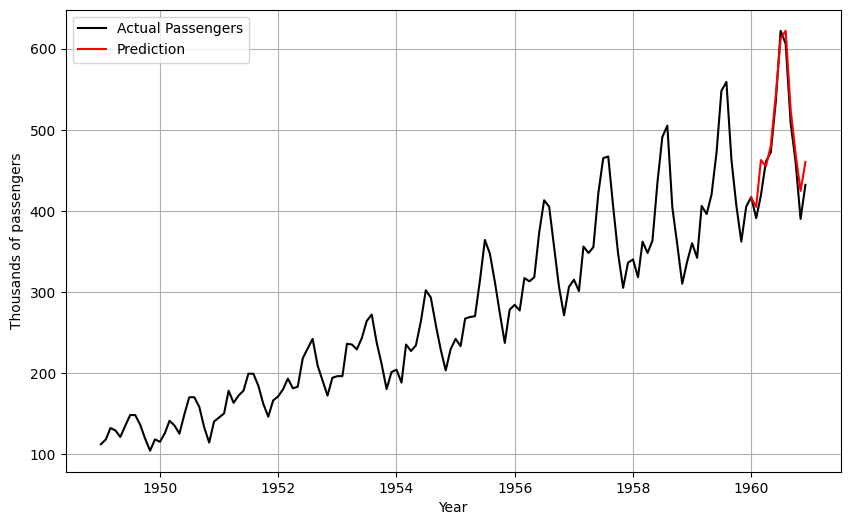

Mean Absolute Error in the test data: 16.26


In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import matplotlib.pyplot as plt

# Load AirPassengers.csv dataset into a pandas DataFrame
df = pd.read_csv("AirPassengers.csv")

# Convert Month column to datetime and create a numeric time index
df["Month"] = pd.to_datetime(df["Month"])
df["Time"] = df.index

seq_length = 12         # months
prediction_time = 12    # months

# Create a stationary time series by computing month-over-month differences
df["PassengersLag"] = df["Passengers"].shift(1)
df["PassengersDiff"] = df.apply(lambda row:
    row["Passengers"] - row["PassengersLag"], axis=1)

# Create lag features (past 11 months of differences as inputs)
for i in range(1, seq_length):
    df["PassengersDiffLag" + str(i)] = df["PassengersDiff"].shift(i)

# Create future features (next 12 months of differences as targets)
for i in range(1, prediction_time + 1):
    df["PassengersDiffFut" + str(i)] = df["PassengersDiff"].shift(-i)

# Split into training (1949-1958) and test (1959-1960) datasets
df_train = df.iloc[:-2*prediction_time]
df_train.dropna(inplace=True)
df_test = df.iloc[-2*prediction_time:]

# Define input variables (current diff + 11 lags) and output variables (next 12 diffs)
input_vars = ["PassengersDiff"]
for i in range(1, seq_length):
    input_vars.append("PassengersDiffLag" + str(i))

output_vars = []
for i in range(1, prediction_time + 1):
    output_vars.append("PassengersDiffFut" + str(i))

# Scale input and output variables using separate StandardScalers
scaler = StandardScaler()
scalero = StandardScaler()

X = np.array(df_train[input_vars])
X_scaled = scaler.fit_transform(X)
X_scaledLSTM = X_scaled.reshape(X.shape[0], X.shape[1], 1)
y = np.array(df_train[output_vars])
y_scaled = scalero.fit_transform(y)

X_test = np.array(df_test[input_vars])
X_testscaled = scaler.transform(X_test)
X_testscaledLSTM = X_testscaled.reshape(X_test.shape[0], X_test.shape[1], 1)

# Fit a Linear Regression model to capture the long-term passenger growth trend (slope)
modelLR = LinearRegression()
XLR = np.array(df_train[["Time"]])
yLR = np.array(df_train[["Passengers"]])
modelLR.fit(XLR, yLR)
slope = modelLR.coef_

# Build LSTM model with 50 units and a Dense output layer for 12-month prediction
modelLSTM = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, input_shape=(seq_length, 1),
                         return_sequences=False),
    tf.keras.layers.Dense(prediction_time)
])

# Compile the LSTM model with Adam optimiser and MSE loss
modelLSTM.compile(
    tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Train the LSTM model on the scaled training data
modelLSTM.fit(
    X_scaledLSTM,
    y_scaled, epochs=200, batch_size=seq_length
)

# Predict the 12 monthly differences for 1960 using December 1959 as input
predictionDiff = scalero.inverse_transform(
    modelLSTM.predict(X_testscaledLSTM[prediction_time - 1].reshape(1, 12, 1))
)

# Reconstruct actual Passengers from differences: Passengers = PrevPassengers + PassengersDiff + trend
prediction = np.zeros(13)
prediction[0] = df_test["Passengers"].iloc[-1-prediction_time]  # anchor to Dec 1959
for i in range(1, 13):
    prediction[i] = prediction[i-1] + predictionDiff[0][i-1] + slope
prediction = np.array(prediction[1:])

# Store predictions in the test DataFrame
df_pred = df_test[-12:]
df_pred["PassengersPred"] = prediction

# Plot actual vs predicted number of passengers for the full dataset
plt.figure(figsize=(10, 6))
plt.plot(df["Month"].values, df["Passengers"].values, color="black", label="Actual Passengers")
plt.plot(df_pred["Month"].values, df_pred["PassengersPred"], color="red", label="Prediction")
plt.xlabel("Year")
plt.ylabel("Thousands of passengers")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

# Evaluate and display model accuracy with Mean Absolute Error for the test dataset
print(f"Mean Absolute Error in the test data: {mean_absolute_error(df_pred['Passengers'].values, df_pred['PassengersPred']):.2f}")